In [1]:
from src.data_management.loaders.volatility_step_loader import VolatilityStepLoader 

volatility_df = VolatilityStepLoader.load()

In [2]:
# Min / Max
rate_min = volatility_df["Rate"].min()
rate_max = volatility_df["Rate"].max()

print(f"Min Rate: {rate_min}")
print(f"Max Rate: {rate_max}")

# También útil: percentiles para ver si los extremos son outliers
print("\nPercentiles:")
print(volatility_df["Rate"].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

# Cuántos valores "raros"
print("\nValores sospechosos:")
print("Rate < -0.1:", (volatility_df["Rate"] < -0.1).sum())
print("Rate > 0.2:", (volatility_df["Rate"] > 0.2).sum())

Min Rate: -1.168405532836914
Max Rate: 2.15433931350708

Percentiles:
0.01   -0.965438
0.05    -0.77193
0.50    -0.53399
0.95   -0.449234
0.99   -0.438001
Name: Rate, dtype: Float64

Valores sospechosos:
Rate < -0.1: 314842
Rate > 0.2: 29


=== DESCRIPTIVOS RATE ===
count    314873.0
mean    -0.550783
std      0.113066
min     -1.168406
25%     -0.595641
50%      -0.53399
75%     -0.462644
max      2.154339
Name: Rate, dtype: Float64

=== CUANTILES ===
0.01   -0.965438
0.05    -0.77193
0.50    -0.53399
0.95   -0.449234
0.99   -0.438001
Name: Rate, dtype: Float64


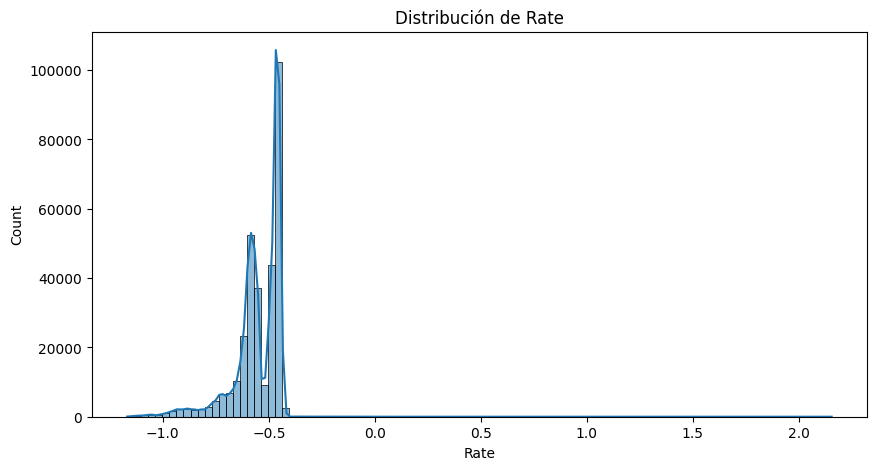

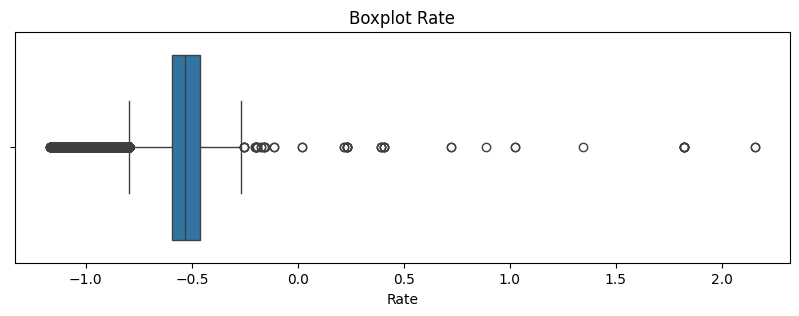

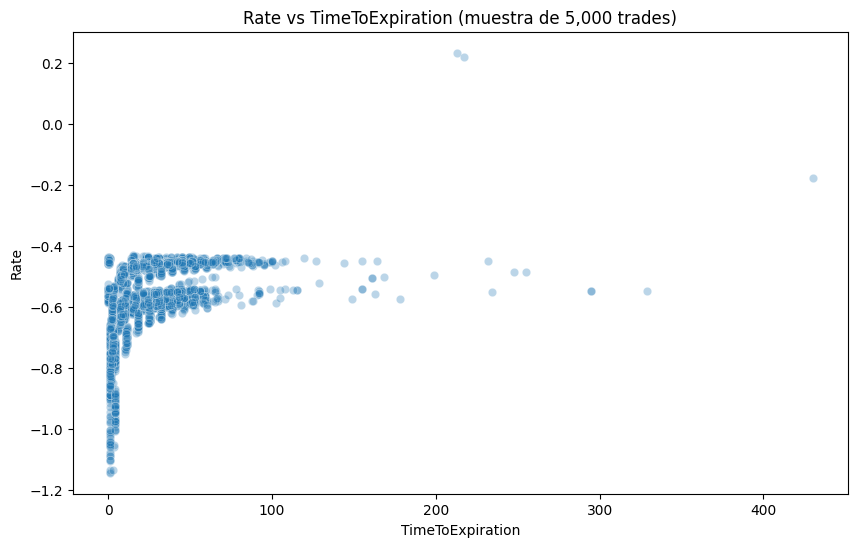


=== RATE POR TIME TO EXPIRATION BIN ===


,mean,median,std,count
TTE_bin,,,,
"(0.013399999999999999, 3.003]",-0.678007,-0.669118,0.172126,31488
"(3.003, 7.337]",-0.67402,-0.643478,0.145094,31487
"(7.337, 11.05]",-0.547507,-0.50892,0.06638,31487
"(11.05, 16.046]",-0.54317,-0.55329,0.076374,31487
"(16.046, 21.213]",-0.534395,-0.516564,0.068861,31488
"(21.213, 24.354]",-0.513309,-0.467916,0.060584,31487
"(24.354, 30.006]",-0.52343,-0.497319,0.065255,31487
"(30.006, 36.21]",-0.510339,-0.482088,0.059791,31487
"(36.21, 46.079]",-0.499395,-0.46242,0.05644,31487


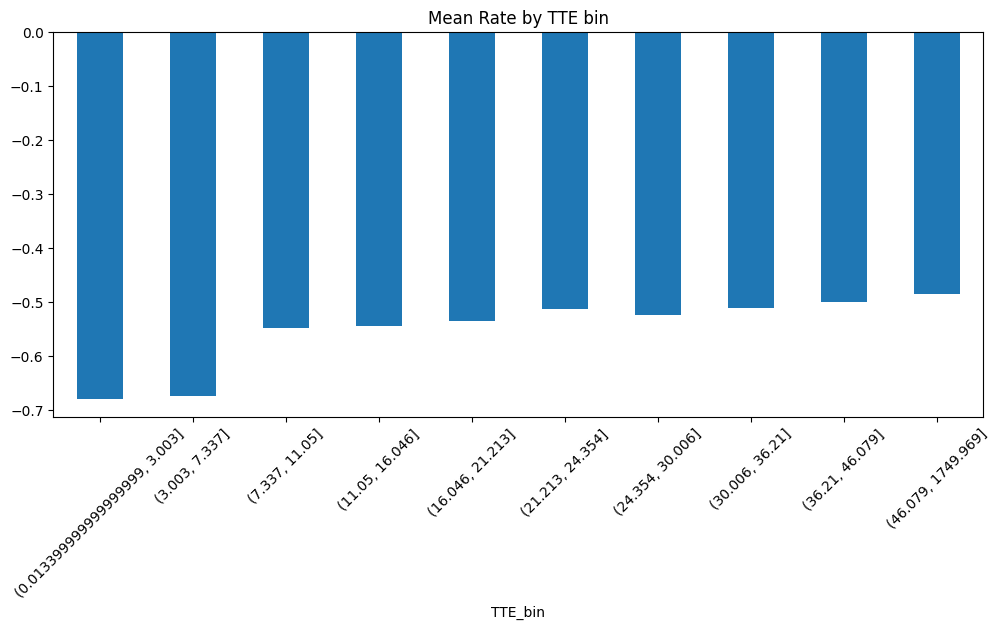

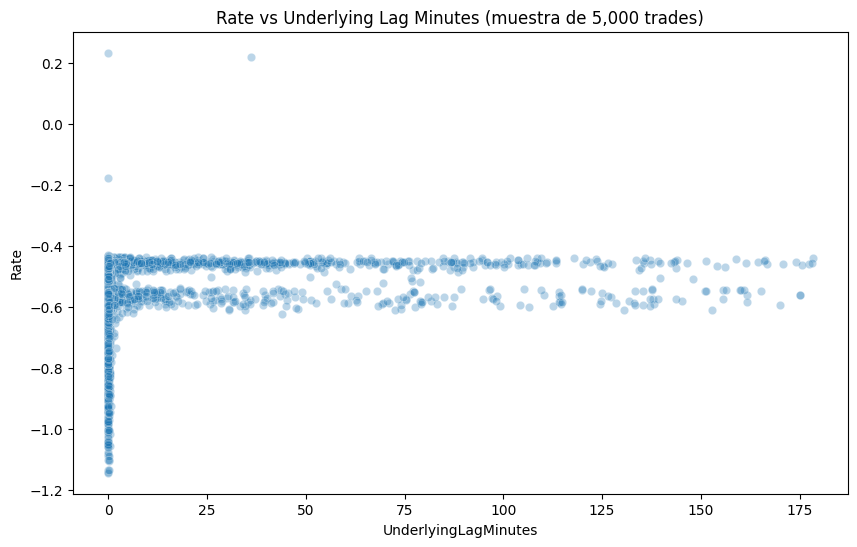

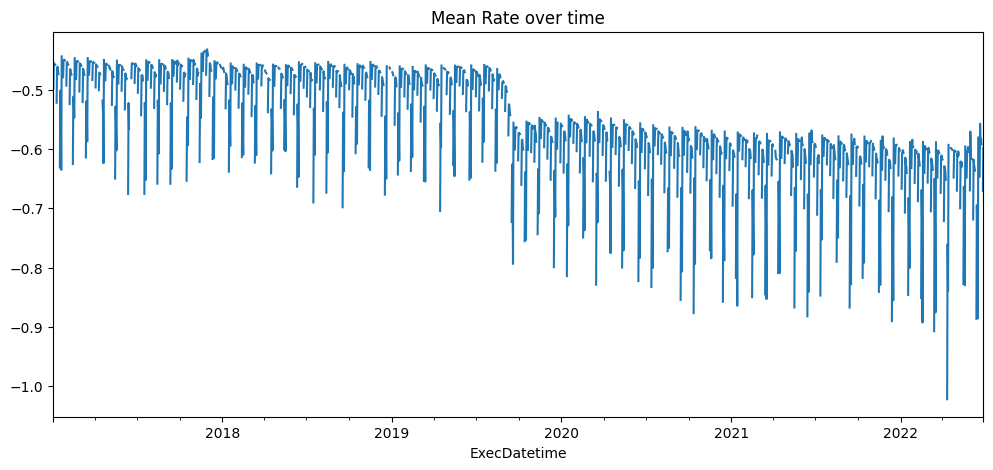

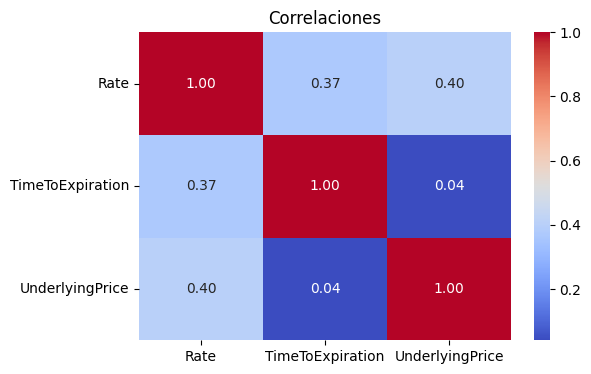


=== CHECKS ===
Valores negativos en Rate: 314842
Valores extremos (|Rate| > 1): 2032

Top extremos:


,Rate,TimeToExpiration,UnderlyingPrice
0,-0.500415,18.344641,9305.0
1,-0.500594,18.338091,9314.0
2,-0.500612,18.337408,9314.0
3,-0.500711,18.333784,9322.0
4,-0.500778,18.331343,9331.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copia para no tocar el original
df = volatility_df.copy()

# --- Limpieza básica ---
# Asegurar tipos
df['Rate'] = pd.to_numeric(df['Rate'])
df['TimeToExpiration'] = pd.to_numeric(df['TimeToExpiration'])
df['UnderlyingPrice'] = pd.to_numeric(df['UnderlyingPrice'])

# Fechas
df['ExecDatetime'] = pd.to_datetime(df['ExecDatetime'])
df['UnderlyingExecDatetime'] = pd.to_datetime(df['UnderlyingExecDatetime'])

# Eliminar nulos clave
df = df.dropna(subset=['Rate', 'TimeToExpiration'])

# --- Overview general ---
print("=== DESCRIPTIVOS RATE ===")
print(df['Rate'].describe())

print("\n=== CUANTILES ===")
print(df['Rate'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

# --- Distribución ---
plt.figure(figsize=(10,5))
sns.histplot(df['Rate'], bins=100, kde=True)
plt.title("Distribución de Rate")
plt.show()

# --- Outliers visual ---
plt.figure(figsize=(10,3))
sns.boxplot(x=df['Rate'])
plt.title("Boxplot Rate")
plt.show()

# --- Relación con TimeToExpiration (muestra, no todos los trades) ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42), 
                x='TimeToExpiration', y='Rate', alpha=0.3)
plt.title("Rate vs TimeToExpiration (muestra de 5,000 trades)")
plt.show()

# --- Binning por TTE ---
df['TTE_bin'] = pd.qcut(df['TimeToExpiration'], q=10, duplicates='drop')

rate_by_tte = df.groupby('TTE_bin')['Rate'].agg(['mean', 'median', 'std', 'count'])
print("\n=== RATE POR TIME TO EXPIRATION BIN ===")
display(rate_by_tte)

rate_by_tte['mean'].plot(kind='bar', figsize=(12,5), title='Mean Rate by TTE bin')
plt.xticks(rotation=45)
plt.show()

# --- Relación con lag del underlying ---
if 'UnderlyingLagMinutes' in df.columns:
    df['UnderlyingLagMinutes'] = pd.to_numeric(df['UnderlyingLagMinutes'], errors='coerce')
    
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42),
                    x='UnderlyingLagMinutes', y='Rate', alpha=0.3)
    plt.title("Rate vs Underlying Lag Minutes (muestra de 5,000 trades)")
    plt.show()

# --- Evolución temporal ---
df_time = df.set_index('ExecDatetime').sort_index()

df_time['Rate'].resample('1D').mean().plot(figsize=(12,5), title='Mean Rate over time')
plt.show()

# --- Correlaciones ---
cols = ['Rate', 'TimeToExpiration', 'UnderlyingPrice']
corr = df[cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlaciones")
plt.show()

# --- Sanity checks básicos ---
print("\n=== CHECKS ===")

print("Valores negativos en Rate:", (df['Rate'] < 0).sum())
print("Valores extremos (|Rate| > 1):", (df['Rate'].abs() > 1).sum())

# Opcional: ver extremos
extreme_rates = df[np.abs(df['Rate']) > df['Rate'].quantile(0.99)]
print("\nTop extremos:")
display(extreme_rates[['Rate', 'TimeToExpiration', 'UnderlyingPrice']].head())

## Deep dive de Rate orientado a validación experta

Este bloque prioriza trades **importantes** (por `Quantity`) y combina magnitud de `Rate` + tamaño para identificar observaciones que más impacto pueden tener en decisiones o calibraciones.

Qué vas a obtener:
- tabla de distribución de `Rate` por buckets y su peso en volumen
- comportamiento de `Rate` por `TTE` y por cuantiles de `Quantity`
- ranking de trades prioritarios por tamaño
- ranking de trades prioritarios por score de rareza ponderado por tamaño

=== FILAS VÁLIDAS PARA ANÁLISIS ===
314873

=== DESCRIPTIVOS CLAVE ===


,Rate,TimeToExpiration,UnderlyingPrice,Quantity
count,314873.000000,314873.000000,314873.000000,314873.000000
mean,-0.550783,23.785904,9185.010369,24.425854
std,0.113066,24.250182,1001.076119,386.027403
min,-1.168406,0.014440,5777.000000,1.000000
1%,-0.965438,0.170587,6610.000000,1.000000
5%,-0.771930,1.194077,7032.000000,1.000000
50%,-0.533990,21.213125,9237.000000,1.000000
95%,-0.449234,56.205341,10629.000000,20.000000
99%,-0.438001,88.005742,10921.000000,250.000000
max,2.154339,1749.969116,11179.000000,40000.000000



=== CHEQUEO DE OUTLIERS DE RATE ===
Max Rate: 2.154339
Min Rate: -1.168406
Trades con |Rate| > 1: 2032
Trades con |Rate| > 5: 0

=== DISTRIBUCIÓN DE RATE POR BUCKET (PONDERADA POR QUANTITY) ===


,n_trades,qty_total,rate_mean,rate_median,pct_trades,pct_qty
RateBucket,,,,,,
<-5%,314842,"7,649,235",-0.5509,-0.5341,99.99%,99.46%
>10%,29,"37,807",0.8831,0.4056,0.01%,0.49%
0% a 2%,2,"4,000",0.0190,0.0190,0.00%,0.05%
-5% a 0%,0,0,nan,nan,0.00%,0.00%
2% a 5%,0,0,nan,nan,0.00%,0.00%
5% a 10%,0,0,nan,nan,0.00%,0.00%



=== RATE POR BIN DE TTE ===


,n_trades,qty_total,rate_mean,rate_median,rate_wavg_qty,rate_std
TTE_bin_q,,,,,,
"(43.321, 1749.969]",39359.000000,"2,199,569",-0.4857,-0.4574,-0.4574,0.0673
"(25.283, 32.077]",39359.000000,"884,488",-0.5113,-0.4691,-0.4995,0.0607
"(9.207, 15.154]",39359.000000,"862,011",-0.5505,-0.5571,-0.5513,0.0756
"(0.013399999999999999, 3.296]",39360.000000,"861,059",-0.6711,-0.6618,-0.6718,0.1605
"(32.077, 43.321]",39359.000000,"853,888",-0.5060,-0.4749,-0.5054,0.0586
"(21.213, 25.283]",39359.000000,"708,633",-0.5216,-0.4970,-0.5250,0.0638
"(3.296, 9.207]",39359.000000,"661,408",-0.6295,-0.6108,-0.6160,0.1442
"(15.154, 21.213]",39359.000000,"659,986",-0.5306,-0.5137,-0.5139,0.0675



=== TOP 30 TRADES PRIORITARIOS (RAREZA * TAMAÑO) ===


,ExecDatetime,OptionContractCode,FutureContractCode,OptionType,Rate,Quantity,TimeToExpiration,UnderlyingPrice,TradePriceOption,TradeType,UnderlyingLagMinutes,rate_z_abs,importance_score
311233,2022-05-31 17:48:13.782943,PIBX 8600Z23,FIBXZ3,P,2.154339,1000.0,562.987366,8585.0,865.0,H,0.0,23.776678,164.267238
311232,2022-05-31 17:48:13.782943,CIBX 8600Z23,FIBXZ3,C,2.154339,1000.0,562.987366,8585.0,840.0,H,0.0,23.776678,164.267238
301038,2022-03-15 10:17:28.185264,CIBX 7800Z23,FIBXZ3,C,1.821738,2000.0,640.300354,7580.0,815.0,H,0.0,20.835020,158.375372
301037,2022-03-15 10:17:28.185264,PIBX 7800Z23,FIBXZ3,P,1.821738,2000.0,640.300354,7580.0,1010.0,H,0.0,20.835020,158.375372
301026,2022-03-15 10:08:20.580507,PIBX 7800Z23,FIBXZ3,P,1.821720,2000.0,640.306702,7580.0,1010.0,X,5.820549,20.834861,158.374162
301025,2022-03-15 10:08:13.596682,CIBX 7800Z23,FIBXZ3,C,1.821720,2000.0,640.306763,7580.0,815.0,X,5.704151,20.834859,158.374146
301019,2022-03-15 10:02:31.347608,CIBX 7800Z23,FIBXZ3,C,1.821709,2000.0,640.310730,7580.0,815.0,H,0.0,20.834760,158.373392
301018,2022-03-15 10:02:31.347608,PIBX 7800Z23,FIBXZ3,P,1.821709,2000.0,640.310730,7580.0,1010.0,H,0.0,20.834760,158.373392
310608,2022-05-26 15:10:17.600896,PIBX 8000M23,FIBXM3,P,1.346561,2000.0,386.097015,8300.0,608.0,H,0.0,16.632355,126.429225
264732,2021-05-03 14:15:23.485884,CIBX 9000Z23,FIBXZ3,C,1.024292,1000.0,956.135132,8130.0,620.0,H,0.0,13.782082,95.217026


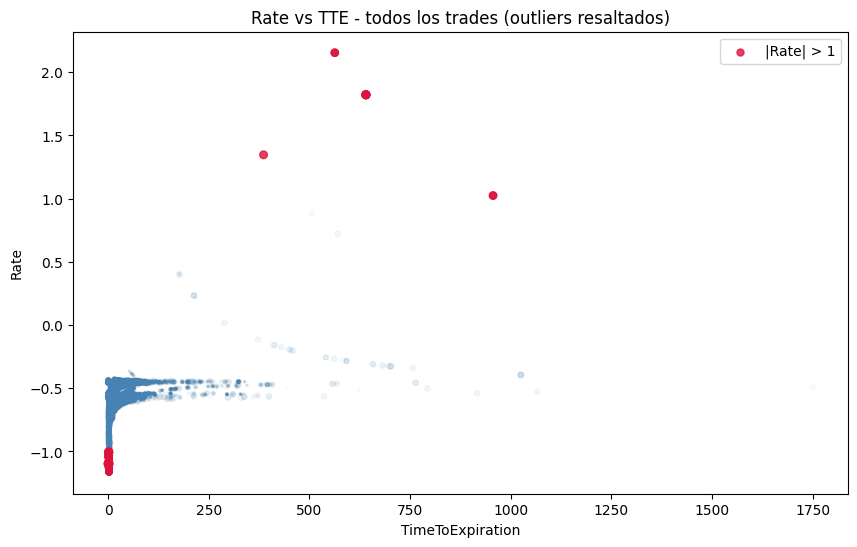

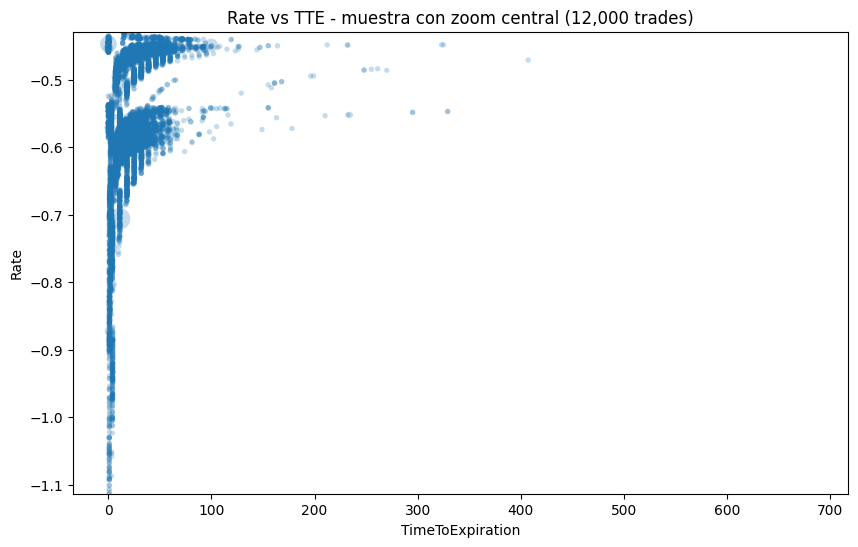

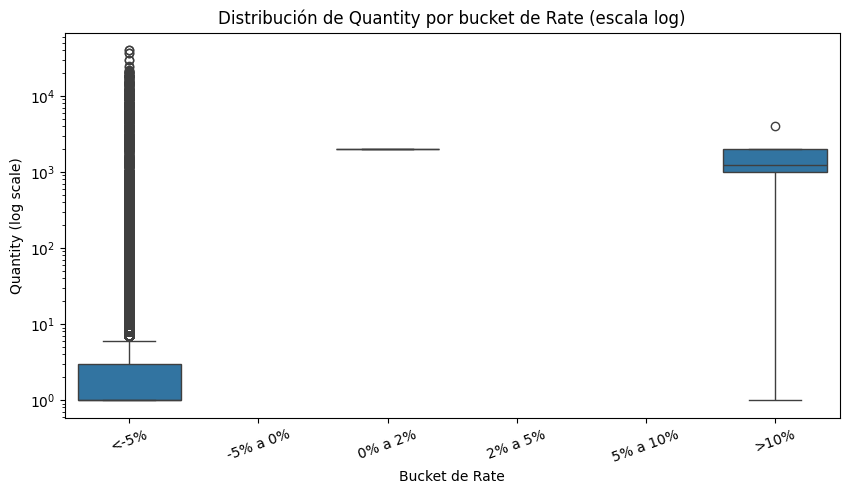

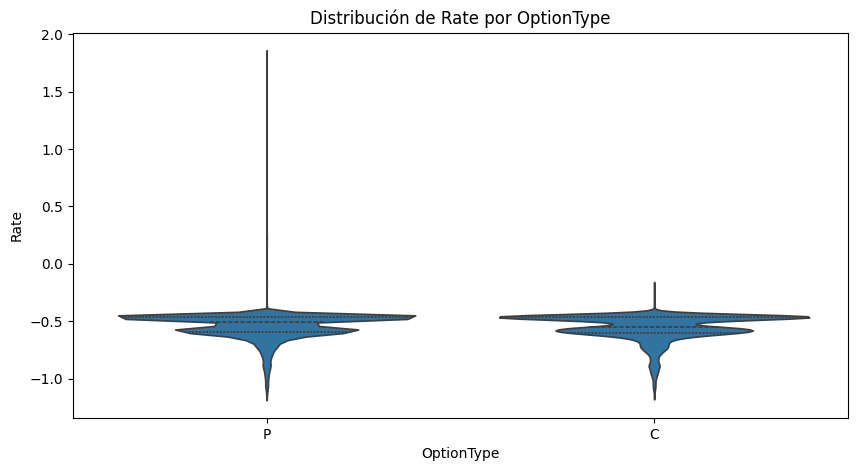

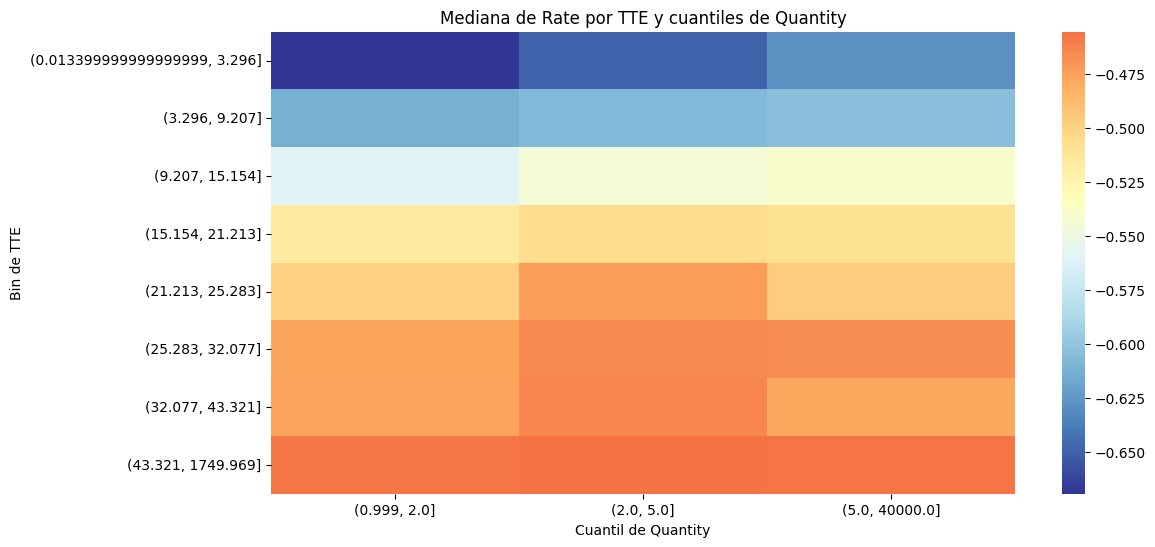


=== RESUMEN RÁPIDO PARA COMENTAR CON EXPERTOS ===
- En la gráfica de muestra pueden no aparecer outliers raros; la gráfica de todos los trades sí los pinta.
- Revisar si buckets altos de Rate concentran poco volumen (posible ruido) o mucho volumen (impacto real).
- Validar monotonicidad/estructura de Rate por TTE usando rate_wavg_qty en la tabla de TTE.
- Priorizar revisión manual de TOP Quantity y TOP importance_score.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Deep dive de Rate con foco en trades relevantes (Quantity)
# ==========================================================
analysis_df = df.copy()

# Estandarizar columnas numéricas necesarias
analysis_df['Rate'] = pd.to_numeric(analysis_df['Rate'], errors='coerce').astype(float)
analysis_df['TimeToExpiration'] = pd.to_numeric(analysis_df['TimeToExpiration'], errors='coerce').astype(float)
analysis_df['UnderlyingPrice'] = pd.to_numeric(analysis_df['UnderlyingPrice'], errors='coerce').astype(float)
analysis_df['Quantity'] = pd.to_numeric(analysis_df['Quantity'], errors='coerce').astype(float)

analysis_df = analysis_df.dropna(subset=['Rate', 'TimeToExpiration', 'Quantity'])
analysis_df = analysis_df[analysis_df['Quantity'] > 0]

print('=== FILAS VÁLIDAS PARA ANÁLISIS ===')
print(len(analysis_df))

print('\n=== DESCRIPTIVOS CLAVE ===')
display(
    analysis_df[['Rate', 'TimeToExpiration', 'UnderlyingPrice', 'Quantity']].describe(
        percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
    )
)

print('\n=== CHEQUEO DE OUTLIERS DE RATE ===')
print(f"Max Rate: {analysis_df['Rate'].max():.6f}")
print(f"Min Rate: {analysis_df['Rate'].min():.6f}")
print(f"Trades con |Rate| > 1: {(analysis_df['Rate'].abs() > 1).sum()}")
print(f"Trades con |Rate| > 5: {(analysis_df['Rate'].abs() > 5).sum()}")

# -----------------------------
# 1) Distribución de Rate
# -----------------------------
rate_bins = [-np.inf, -0.05, 0.00, 0.02, 0.05, 0.10, np.inf]
rate_labels = ['<-5%', '-5% a 0%', '0% a 2%', '2% a 5%', '5% a 10%', '>10%']
analysis_df['RateBucket'] = pd.cut(
    analysis_df['Rate'], bins=rate_bins, labels=rate_labels, include_lowest=True
)

bucket_table = (
    analysis_df.groupby('RateBucket', observed=False)
    .agg(
        n_trades=('Rate', 'size'),
        qty_total=('Quantity', 'sum'),
        rate_mean=('Rate', 'mean'),
        rate_median=('Rate', 'median'),
    )
    .sort_values('qty_total', ascending=False)
)
bucket_table['pct_trades'] = bucket_table['n_trades'] / bucket_table['n_trades'].sum()
bucket_table['pct_qty'] = bucket_table['qty_total'] / bucket_table['qty_total'].sum()

print('\n=== DISTRIBUCIÓN DE RATE POR BUCKET (PONDERADA POR QUANTITY) ===')
display(bucket_table.style.format({
    'rate_mean': '{:.4f}',
    'rate_median': '{:.4f}',
    'pct_trades': '{:.2%}',
    'pct_qty': '{:.2%}',
    'qty_total': '{:,.0f}',
}))

# -----------------------------
# 2) Rate vs TTE (ponderado por tamaño)
# -----------------------------
analysis_df['TTE_bin_q'] = pd.qcut(
    analysis_df['TimeToExpiration'], q=8, duplicates='drop'
 )

tte_table = (
    analysis_df.groupby('TTE_bin_q', observed=False)
    .apply(
        lambda g: pd.Series({
            'n_trades': len(g),
            'qty_total': g['Quantity'].sum(),
            'rate_mean': g['Rate'].mean(),
            'rate_median': g['Rate'].median(),
            'rate_wavg_qty': np.average(g['Rate'], weights=g['Quantity']),
            'rate_std': g['Rate'].std(),
        })
    )
    .sort_values('qty_total', ascending=False)
)

print('\n=== RATE POR BIN DE TTE ===')
display(tte_table.style.format({
    'rate_mean': '{:.4f}',
    'rate_median': '{:.4f}',
    'rate_wavg_qty': '{:.4f}',
    'rate_std': '{:.4f}',
    'qty_total': '{:,.0f}',
}))

# -----------------------------
# 3) Top trades por tamaño y por score de rareza
# -----------------------------
top_qty_trades = analysis_df.sort_values('Quantity', ascending=False).head(30)

cols_top = [
    'ExecDatetime', 'OptionContractCode', 'FutureContractCode', 'OptionType',
    'Rate', 'Quantity', 'TimeToExpiration', 'UnderlyingPrice',
    'TradePriceOption', 'TradeType', 'UnderlyingLagMinutes',
 ]
cols_top = [c for c in cols_top if c in analysis_df.columns]

# Score de rareza: z-score de Rate * log(1 + Quantity)
rate_std = analysis_df['Rate'].std()
rate_std = rate_std if pd.notna(rate_std) and rate_std > 0 else 1e-9
analysis_df['rate_z_abs'] = (analysis_df['Rate'] - analysis_df['Rate'].median()).abs() / rate_std
analysis_df['importance_score'] = analysis_df['rate_z_abs'] * np.log1p(analysis_df['Quantity'])

priority_trades = analysis_df.sort_values('importance_score', ascending=False).head(30)

print('\n=== TOP 30 TRADES PRIORITARIOS (RAREZA * TAMAÑO) ===')
display(priority_trades[cols_top + ['rate_z_abs', 'importance_score']])

# -----------------------------
# 4) Visuales para discusión con expertos
# -----------------------------
plot_df = analysis_df.sample(min(12000, len(analysis_df)), random_state=42).copy()
extreme_plot_df = analysis_df[analysis_df['Rate'].abs() > 1].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    analysis_df['TimeToExpiration'],
    analysis_df['Rate'],
    s=np.clip(np.log1p(analysis_df['Quantity']) * 2, 2, 30),
    alpha=0.03,
    color='steelblue'
 )
if not extreme_plot_df.empty:
    plt.scatter(
        extreme_plot_df['TimeToExpiration'],
        extreme_plot_df['Rate'],
        s=np.clip(np.log1p(extreme_plot_df['Quantity']) * 4, 12, 80),
        alpha=0.8,
        color='crimson',
        label='|Rate| > 1'
    )
    plt.legend()
plt.title('Rate vs TTE - todos los trades (outliers resaltados)')
plt.xlabel('TimeToExpiration')
plt.ylabel('Rate')
plt.show()

zoom_limit_low = analysis_df['Rate'].quantile(0.001)
zoom_limit_high = analysis_df['Rate'].quantile(0.999)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x='TimeToExpiration',
    y='Rate',
    size='Quantity',
    sizes=(15, 300),
    alpha=0.25,
    linewidth=0,
    legend=False,
 )
plt.ylim(zoom_limit_low, zoom_limit_high)
plt.title('Rate vs TTE - muestra con zoom central (12,000 trades)')
plt.xlabel('TimeToExpiration')
plt.ylabel('Rate')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=analysis_df, x='RateBucket', y='Quantity')
plt.yscale('log')
plt.title('Distribución de Quantity por bucket de Rate (escala log)')
plt.xlabel('Bucket de Rate')
plt.ylabel('Quantity (log scale)')
plt.xticks(rotation=20)
plt.show()

if 'OptionType' in analysis_df.columns:
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=plot_df, x='OptionType', y='Rate', inner='quartile')
    plt.title('Distribución de Rate por OptionType')
    plt.xlabel('OptionType')
    plt.ylabel('Rate')
    plt.show()

# Heatmap de mediana de Rate por TTE bin y tamaño de trade
analysis_df['Qty_bin_q'] = pd.qcut(analysis_df['Quantity'], q=6, duplicates='drop')
heat = analysis_df.pivot_table(
    index='TTE_bin_q', columns='Qty_bin_q', values='Rate', aggfunc='median'
 )
heat = heat.astype(float)

plt.figure(figsize=(12, 6))
sns.heatmap(heat, cmap='RdYlBu_r', center=float(analysis_df['Rate'].median()), annot=False)
plt.title('Mediana de Rate por TTE y cuantiles de Quantity')
plt.xlabel('Cuantil de Quantity')
plt.ylabel('Bin de TTE')
plt.show()

print('\n=== RESUMEN RÁPIDO PARA COMENTAR CON EXPERTOS ===')
print('- En la gráfica de muestra pueden no aparecer outliers raros; la gráfica de todos los trades sí los pinta.')
print('- Revisar si buckets altos de Rate concentran poco volumen (posible ruido) o mucho volumen (impacto real).')
print('- Validar monotonicidad/estructura de Rate por TTE usando rate_wavg_qty en la tabla de TTE.')
print('- Priorizar revisión manual de TOP Quantity y TOP importance_score.')

In [5]:
# Top 100 trades con mayor |Rate| mostrando toda la información
base_df = analysis_df.copy() if 'analysis_df' in globals() else df.copy()

base_df['Rate'] = pd.to_numeric(base_df['Rate'], errors='coerce').astype(float)
top_100_abs_rate = (
    base_df.dropna(subset=['Rate'])
    .assign(abs_rate=lambda x: x['Rate'].abs())
    .sort_values('abs_rate', ascending=False)
    .head(100)
)

print('=== TOP 100 TRADES POR |RATE| ===')
print(f'Trades mostrados: {len(top_100_abs_rate)}')

# Mostrar toda la info sin recortes
with pd.option_context(
    'display.max_rows', 200,
    'display.max_columns', None,
    'display.width', 2000,
    'display.max_colwidth', None
 ):
    display(top_100_abs_rate)

=== TOP 100 TRADES POR |RATE| ===
Trades mostrados: 100


,OptionContractCode,FutureContractCode,UnderlyingPrice,SessionDate,MarketCode,TradeExecID,TradePriceOption,Quantity,TradeType,StrikePrice,MaturityDatetime,ExecTime,ExecDatetime,TimeToExpiration,UnderlyingExecDatetime,UnderlyingLagMinutes,Rate,OptionType,ImpliedVolatility,TTE_bin,RateBucket,TTE_bin_q,rate_z_abs,importance_score,Qty_bin_q,abs_rate
311232,CIBX 8600Z23,FIBXZ3,8585.0,2022-05-31,M3,100136894,840.0,1000.0,H,8600.0,2023-12-15 17:30:00,1900-01-01 17:48:13.782943,2022-05-31 17:48:13.782943,562.987366,2022-05-31 17:48:13.782943,0.0,2.154339,C,0.206295,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",23.776678,164.267238,"(5.0, 40000.0]",2.154339
311233,PIBX 8600Z23,FIBXZ3,8585.0,2022-05-31,M3,100136895,865.0,1000.0,H,8600.0,2023-12-15 17:30:00,1900-01-01 17:48:13.782943,2022-05-31 17:48:13.782943,562.987366,2022-05-31 17:48:13.782943,0.0,2.154339,P,0.208864,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",23.776678,164.267238,"(5.0, 40000.0]",2.154339
301037,PIBX 7800Z23,FIBXZ3,7580.0,2022-03-15,M3,100119200,1010.0,2000.0,H,7800.0,2023-12-15 17:30:00,1900-01-01 10:17:28.185264,2022-03-15 10:17:28.185264,640.300354,2022-03-15 10:17:28.185264,0.0,1.821738,P,0.229441,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",20.835020,158.375372,"(5.0, 40000.0]",1.821738
301038,CIBX 7800Z23,FIBXZ3,7580.0,2022-03-15,M3,100119199,815.0,2000.0,H,7800.0,2023-12-15 17:30:00,1900-01-01 10:17:28.185264,2022-03-15 10:17:28.185264,640.300354,2022-03-15 10:17:28.185264,0.0,1.821738,C,0.23411,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",20.835020,158.375372,"(5.0, 40000.0]",1.821738
301026,PIBX 7800Z23,FIBXZ3,7580.0,2022-03-15,M3,100119180,1010.0,2000.0,X,7800.0,2023-12-15 17:30:00,1900-01-01 10:08:20.580507,2022-03-15 10:08:20.580507,640.306702,2022-03-15 10:02:31.347608,5.820549,1.821720,P,0.22944,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",20.834861,158.374162,"(5.0, 40000.0]",1.821720
301025,CIBX 7800Z23,FIBXZ3,7580.0,2022-03-15,M3,100119178,815.0,2000.0,X,7800.0,2023-12-15 17:30:00,1900-01-01 10:08:13.596682,2022-03-15 10:08:13.596682,640.306763,2022-03-15 10:02:31.347608,5.704151,1.821720,C,0.234109,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",20.834859,158.374146,"(5.0, 40000.0]",1.821720
301018,PIBX 7800Z23,FIBXZ3,7580.0,2022-03-15,M3,100119173,1010.0,2000.0,H,7800.0,2023-12-15 17:30:00,1900-01-01 10:02:31.347608,2022-03-15 10:02:31.347608,640.310730,2022-03-15 10:02:31.347608,0.0,1.821709,P,0.229439,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",20.834760,158.373392,"(5.0, 40000.0]",1.821709
301019,CIBX 7800Z23,FIBXZ3,7580.0,2022-03-15,M3,100119172,815.0,2000.0,H,7800.0,2023-12-15 17:30:00,1900-01-01 10:02:31.347608,2022-03-15 10:02:31.347608,640.310730,2022-03-15 10:02:31.347608,0.0,1.821709,C,0.234108,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",20.834760,158.373392,"(5.0, 40000.0]",1.821709
310608,PIBX 8000M23,FIBXM3,8300.0,2022-05-26,M3,100135572,608.0,2000.0,H,8000.0,2023-06-16 17:30:00,1900-01-01 15:10:17.600896,2022-05-26 15:10:17.600896,386.097015,2022-05-26 15:10:17.600896,0.0,1.346561,P,0.226999,"(46.079, 1749.969]",>10%,"(43.321, 1749.969]",16.632355,126.429225,"(5.0, 40000.0]",1.346561
304813,PIBX 8500J22,FIBXJ2,8545.0,2022-04-11,M3,100126255,59.0,1.0,M,8500.0,2022-04-14 17:30:00,1900-01-01 17:29:10.500828,2022-04-11 17:29:10.500828,3.000573,2022-04-11 17:29:09.533565,0.016121,-1.168406,P,0.257816,"(0.013399999999999999, 3.003]",<-5%,"(0.013399999999999999, 3.296]",5.611026,3.889267,"(0.999, 2.0]",1.168406


In [6]:
# Top 100 trades con mayor TTE mostrando toda la información
base_df = analysis_df.copy() if 'analysis_df' in globals() else df.copy()

base_df['Rate'] = pd.to_numeric(base_df['Rate'], errors='coerce').astype(float)
base_df['TimeToExpiration'] = pd.to_numeric(base_df['TimeToExpiration'], errors='coerce').astype(float)

top_100_tte = (
    base_df.dropna(subset=['TimeToExpiration'])
    .sort_values('TimeToExpiration', ascending=False)
    .head(100)
)

print('=== TOP 100 TRADES POR MAYOR TTE ===')
print(f'Trades mostrados: {len(top_100_tte)}')

with pd.option_context(
    'display.max_rows', 200,
    'display.max_columns', None,
    'display.width', 2000,
    'display.max_colwidth', None
 ):
    display(top_100_tte)

=== TOP 100 TRADES POR MAYOR TTE ===
Trades mostrados: 100


,OptionContractCode,FutureContractCode,UnderlyingPrice,SessionDate,MarketCode,TradeExecID,TradePriceOption,Quantity,TradeType,StrikePrice,MaturityDatetime,ExecTime,ExecDatetime,TimeToExpiration,UnderlyingExecDatetime,UnderlyingLagMinutes,Rate,OptionType,ImpliedVolatility,TTE_bin,RateBucket,TTE_bin_q,rate_z_abs,importance_score,Qty_bin_q
13155,PIBX 8000Z21,FIBXZ1,8300.0,2017-03-03,M3,OM0001663802,1470.0,1000.0,H,8000.0,2021-12-17 17:30:00,1900-01-01 18:14:32,2017-03-03 18:14:32.000000,1749.969116,2017-03-03 18:14:24.000000,0.133333,-0.491586,P,0.224367,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",0.375042,2.591072,"(5.0, 40000.0]"
145990,PIBX 6200Z21,FIBXZ1,7850.0,2019-01-16,M3,OM0001859084,352.0,500.0,H,6200.0,2021-12-17 17:30:00,1900-01-01 18:05:28.293583,2019-01-16 18:05:28.293583,1065.975342,2019-01-16 18:05:28.278274,0.000255,-0.527411,P,0.20086,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",0.058186,0.361720,"(5.0, 40000.0]"
145991,PIBX 6200Z21,FIBXZ1,7850.0,2019-01-16,M3,OM0001859086,352.0,1000.0,H,6200.0,2021-12-17 17:30:00,1900-01-01 18:22:11.243009,2019-01-16 18:22:11.243009,1065.963745,2019-01-16 18:05:28.278274,16.71608,-0.527417,P,0.200861,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",0.058136,0.401644,"(5.0, 40000.0]"
212876,PIBX 7500Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960869,450.0,2000.0,H,7500.0,2022-12-16 17:30:00,1900-01-01 17:25:01.019880,2020-02-25 17:25:01.019880,1025.003418,2020-02-25 17:24:42.993252,0.300444,-0.394757,P,0.176842,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231439,9.360664,"(5.0, 40000.0]"
212877,PIBX10000Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960868,1705.0,1000.0,H,10000.0,2022-12-16 17:30:00,1900-01-01 17:25:01.019880,2020-02-25 17:25:01.019880,1025.003418,2020-02-25 17:24:42.993252,0.300444,-0.394757,P,0.155073,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231439,8.507711,"(5.0, 40000.0]"
212886,PIBX 7500Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960883,450.0,6000.0,H,7500.0,2022-12-16 17:30:00,1900-01-01 17:32:39.521300,2020-02-25 17:32:39.521300,1024.998169,2020-02-25 17:25:01.020704,7.641676,-0.394759,P,0.176842,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231421,10.712975,"(5.0, 40000.0]"
212887,PIBX10000Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960882,1705.0,3000.0,H,10000.0,2022-12-16 17:30:00,1900-01-01 17:32:39.521300,2020-02-25 17:32:39.521300,1024.998169,2020-02-25 17:25:01.020704,7.641676,-0.394759,P,0.155073,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231421,9.859623,"(5.0, 40000.0]"
212890,PIBX 7500Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960888,450.0,3000.0,H,7500.0,2022-12-16 17:30:00,1900-01-01 17:36:26.126776,2020-02-25 17:36:26.126776,1024.995483,2020-02-25 17:32:39.522026,3.776746,-0.394760,P,0.176843,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231412,9.859550,"(5.0, 40000.0]"
212889,PIBX10000Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960887,1705.0,1500.0,H,10000.0,2022-12-16 17:30:00,1900-01-01 17:36:26.126776,2020-02-25 17:36:26.126776,1024.995483,2020-02-25 17:32:39.522026,3.776746,-0.394760,P,0.155073,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231412,9.006410,"(5.0, 40000.0]"
212891,PIBX10000Z22,FIBXZ2,8800.0,2020-02-25,M3,OM0001960890,1705.0,1000.0,H,10000.0,2022-12-16 17:30:00,1900-01-01 17:52:55.109483,2020-02-25 17:52:55.109483,1024.984131,2020-02-25 17:36:26.127507,16.483032,-0.394764,P,0.155074,"(46.079, 1749.969]",<-5%,"(43.321, 1749.969]",1.231374,8.507258,"(5.0, 40000.0]"
